# 02 — Análisis Exploratorio de Datos (EDA)
**Proyecto:** PredictRent — Predicción de precios de alquiler en Lima Metropolitana  
**Dataset:** `inmuebles_clean_v1.csv`  
**Objetivo:** Entender la distribución del target, identificar las variables más relevantes y detectar patrones que guíen las decisiones de modelado.

---
## Índice
1. Carga del dataset
2. Análisis del target (`precio_usd`)
3. Distribución por fuente y tipo de propiedad
4. Variables numéricas: distribución y relación con el precio
5. Variables geográficas: precio por distrito
6. Amenities: impacto en el precio
7. Correlaciones
8. Conclusiones del EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
FIGURES = '../reports/figures/'

df = pd.read_csv('../data/processed/inmuebles_clean_v1.csv')
print(f'Shape: {df.shape}')
df.head(2)

Shape: (3348, 75)


,id_portal,url,fuente,precio_usd,area_final_m2,dormitorios,banos,cocheras,antiguedad_anios,amenities_count,...,tiene_caseta_de_guardia,tiene_frente_a_parque,tiene_cerco_de_material_noble,tiene_portero_electrico,tiene_av_acceso_afirmada,tiene_duplex,tiene_frente_al_mar_primera_fila,tiene_jacuzzi,cocheras_informadas,es_estudio
0,50441814,https://www.adondevivir.com/propiedades/clasif...,adondevivir,2000.0,210.0,3.0,2.0,2.0,12.0,19.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1,0
1,50795573,https://www.adondevivir.com/propiedades/clasif...,adondevivir,650.0,60.0,1.0,1.0,1.0,3.0,13.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1,0


---
## 2. Análisis del target: `precio_usd`

El target es continuo y corresponde al precio mensual de alquiler en USD. Lo primero es entender su distribución y si necesita transformación.

In [2]:
print('=== Estadísticas del target ===')
print(df['precio_usd'].describe().round(2))
print(f'\nSkewness:  {df["precio_usd"].skew():.3f}')
print(f'Kurtosis:  {df["precio_usd"].kurt():.3f}')

=== Estadísticas del target ===
count    3348.00
mean      982.91
std       748.45
min       200.00
25%       586.67
50%       782.61
75%      1100.00
max      7000.00
Name: precio_usd, dtype: float64

Skewness:  3.307
Kurtosis:  15.505


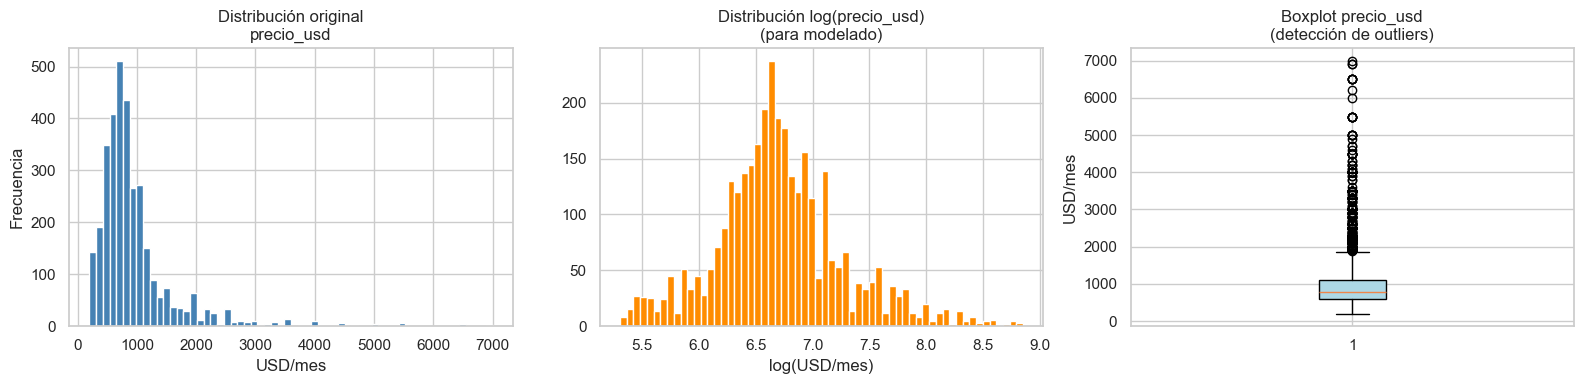

=== Percentiles clave ===
  P 1: $     228
  P 5: $     320
  P25: $     587
  P50: $     783
  P75: $   1,100
  P90: $   1,738
  P95: $   2,300
  P99: $   4,253


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribución original
axes[0].hist(df['precio_usd'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución original\nprecio_usd')
axes[0].set_xlabel('USD/mes')
axes[0].set_ylabel('Frecuencia')

# Distribución log
axes[1].hist(np.log1p(df['precio_usd']), bins=60, color='darkorange', edgecolor='white')
axes[1].set_title('Distribución log(precio_usd)\n(para modelado)')
axes[1].set_xlabel('log(USD/mes)')

# Boxplot con outliers
axes[2].boxplot(df['precio_usd'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[2].set_title('Boxplot precio_usd\n(detección de outliers)')
axes[2].set_ylabel('USD/mes')

plt.tight_layout()
plt.savefig(f'{FIGURES}02_target_distribucion.png', dpi=150)
plt.show()

# Percentiles clave
print('=== Percentiles clave ===')
for p in [1, 5, 25, 50, 75, 90, 95, 99]:
    print(f'  P{p:>2}: ${df["precio_usd"].quantile(p/100):>8,.0f}')

**Observación:** El target presenta sesgo positivo (cola derecha larga), típico en precios inmobiliarios. Esto sugiere que usar `log(precio_usd)` como target durante el entrenamiento puede mejorar la performance del modelo, ya que los algoritmos lineales asumen distribuciones más simétricas.

---
## 3. Distribución por fuente y tipo de propiedad

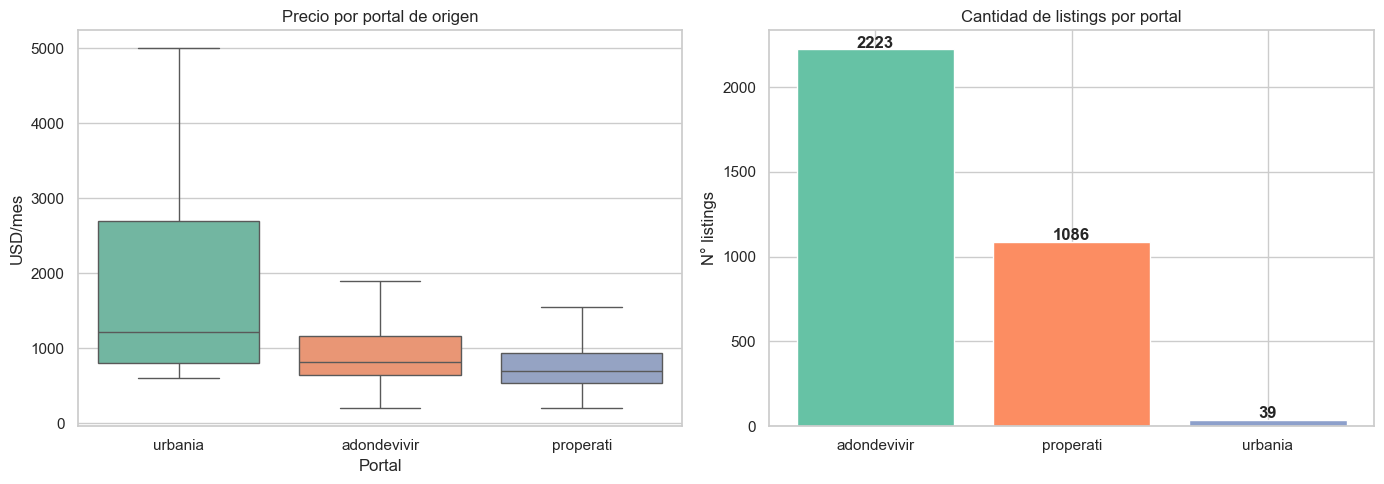

=== Mediana de precio por fuente ===
             median    mean  count
fuente                            
adondevivir   816.0  1039.0   2223
properati     700.0   832.0   1086
urbania      1217.0  1966.0     39


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precio por fuente
order_fuente = df.groupby('fuente')['precio_usd'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='fuente', y='precio_usd', order=order_fuente,
            palette='Set2', ax=axes[0], showfliers=False)
axes[0].set_title('Precio por portal de origen')
axes[0].set_xlabel('Portal')
axes[0].set_ylabel('USD/mes')

# Conteo por fuente
conteo = df['fuente'].value_counts()
axes[1].bar(conteo.index, conteo.values, color=sns.color_palette('Set2', 3))
axes[1].set_title('Cantidad de listings por portal')
axes[1].set_ylabel('N° listings')
for i, v in enumerate(conteo.values):
    axes[1].text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{FIGURES}02_precio_por_fuente.png', dpi=150)
plt.show()

print('=== Mediana de precio por fuente ===')
print(df.groupby('fuente')['precio_usd'].agg(['median','mean','count']).round(0))

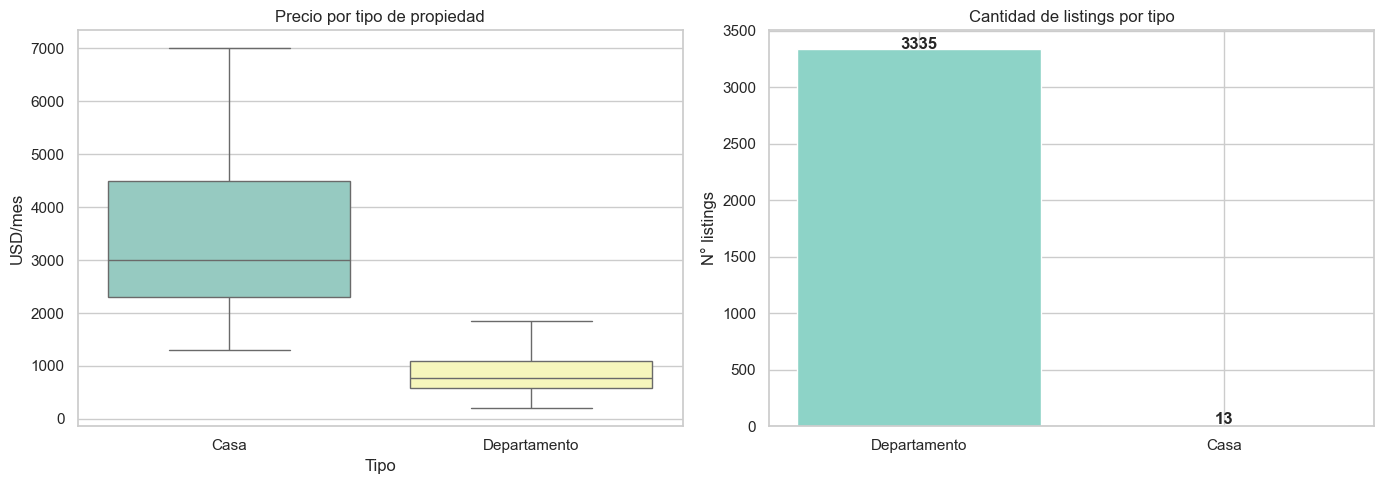

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order_tipo = df.groupby('tipo_propiedad')['precio_usd'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='tipo_propiedad', y='precio_usd', order=order_tipo,
            palette='Set3', ax=axes[0], showfliers=False)
axes[0].set_title('Precio por tipo de propiedad')
axes[0].set_xlabel('Tipo')
axes[0].set_ylabel('USD/mes')

conteo_tipo = df['tipo_propiedad'].value_counts()
axes[1].bar(conteo_tipo.index, conteo_tipo.values, color=sns.color_palette('Set3', len(conteo_tipo)))
axes[1].set_title('Cantidad de listings por tipo')
axes[1].set_ylabel('N° listings')
for i, v in enumerate(conteo_tipo.values):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{FIGURES}02_precio_por_tipo.png', dpi=150)
plt.show()

---
## 4. Variables numéricas: distribución y relación con el precio

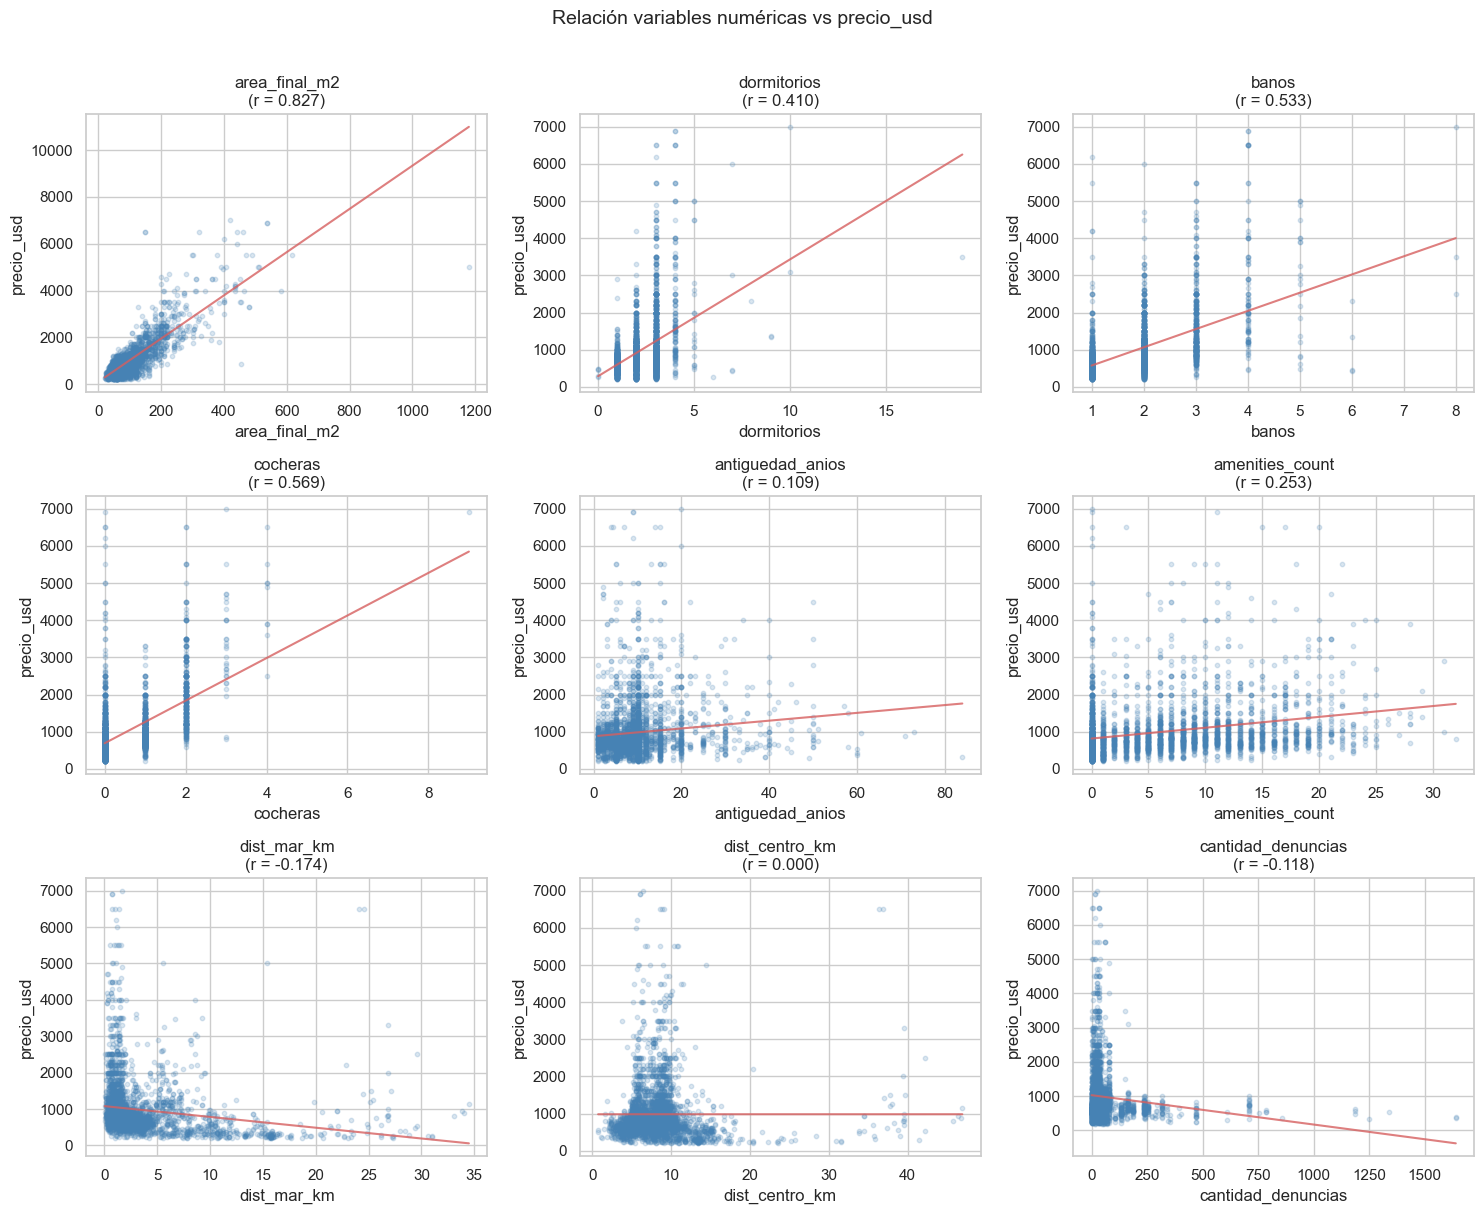

In [6]:
num_cols = ['area_final_m2', 'dormitorios', 'banos', 'cocheras',
            'antiguedad_anios', 'amenities_count', 'dist_mar_km',
            'dist_centro_km', 'cantidad_denuncias']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].scatter(df[col], df['precio_usd'], alpha=0.2, s=10, color='steelblue')
    # Línea de tendencia
    z = np.polyfit(df[col].dropna(), df.loc[df[col].notna(), 'precio_usd'], 1)
    p = np.poly1d(z)
    x_sorted = np.linspace(df[col].min(), df[col].max(), 100)
    axes[i].plot(x_sorted, p(x_sorted), 'r-', linewidth=1.5, alpha=0.8)
    corr = df[['precio_usd', col]].corr().iloc[0,1]
    axes[i].set_title(f'{col}\n(r = {corr:.3f})')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('precio_usd')

plt.suptitle('Relación variables numéricas vs precio_usd', y=1.01, fontsize=14)
plt.tight_layout()
plt.savefig(f'{FIGURES}02_numericas_vs_precio.png', dpi=150, bbox_inches='tight')
plt.show()

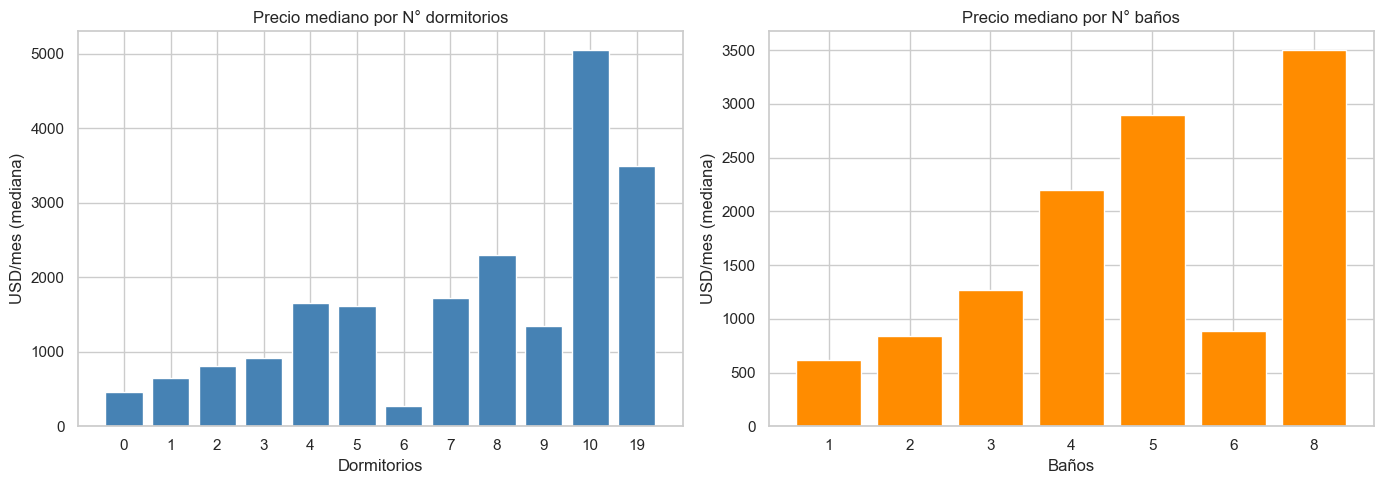

In [7]:
# Precio mediano por número de dormitorios
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

precio_x_dorm = df.groupby('dormitorios')['precio_usd'].median().reset_index()
axes[0].bar(precio_x_dorm['dormitorios'].astype(int).astype(str),
            precio_x_dorm['precio_usd'], color='steelblue')
axes[0].set_title('Precio mediano por N° dormitorios')
axes[0].set_xlabel('Dormitorios')
axes[0].set_ylabel('USD/mes (mediana)')

precio_x_banos = df.groupby('banos')['precio_usd'].median().reset_index()
axes[1].bar(precio_x_banos['banos'].astype(int).astype(str),
            precio_x_banos['precio_usd'], color='darkorange')
axes[1].set_title('Precio mediano por N° baños')
axes[1].set_xlabel('Baños')
axes[1].set_ylabel('USD/mes (mediana)')

plt.tight_layout()
plt.savefig(f'{FIGURES}02_precio_dorm_banos.png', dpi=150)
plt.show()

---
## 5. Variables geográficas: precio por distrito

**Nota:** Se usa `distrito_oficial` (resuelto por point-in-polygon con shapefile INEI), no el distrito declarado por el portal.

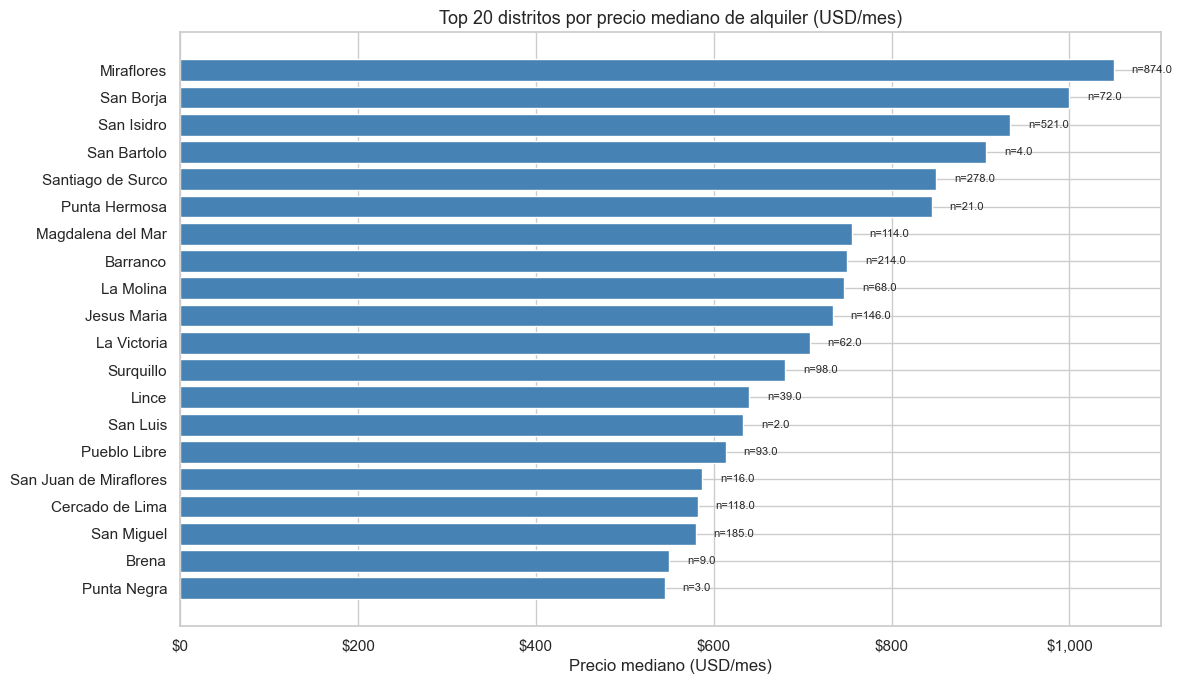


=== Ranking completo ===
                         mediana  conteo
distrito_oficial                        
Miraflores              1050.000     874
San Borja               1000.000      72
San Isidro               933.330     521
San Bartolo              906.665       4
Santiago de Surco        850.000     278
Punta Hermosa            844.930      21
Magdalena del Mar        755.000     114
Barranco                 750.000     214
La Molina                746.670      68
Jesus Maria              733.920     146
La Victoria              707.825      62
Surquillo                680.580      98
Lince                    640.000      39
San Luis                 633.335       2
Pueblo Libre             613.330      93
San Juan de Miraflores   587.000      16
Cercado de Lima          582.000     118
San Miguel               579.710     185
Brena                    550.000       9
Punta Negra              545.000       3
Bellavista               538.115      14
Chorrillos               533.33

In [8]:
precio_distrito = df.groupby('distrito_oficial')['precio_usd'].agg(
    mediana='median', conteo='count'
).sort_values('mediana', ascending=False)

# Top 20 distritos por precio mediano
top20 = precio_distrito.head(20)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top20.index[::-1], top20['mediana'][::-1], color='steelblue')
# Anotar conteo
for bar, (_, row) in zip(bars, top20[::-1].iterrows()):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f'n={row["conteo"]}', va='center', fontsize=8)
ax.set_title('Top 20 distritos por precio mediano de alquiler (USD/mes)', fontsize=13)
ax.set_xlabel('Precio mediano (USD/mes)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig(f'{FIGURES}02_precio_por_distrito.png', dpi=150)
plt.show()

print('\n=== Ranking completo ===')
print(precio_distrito.to_string())

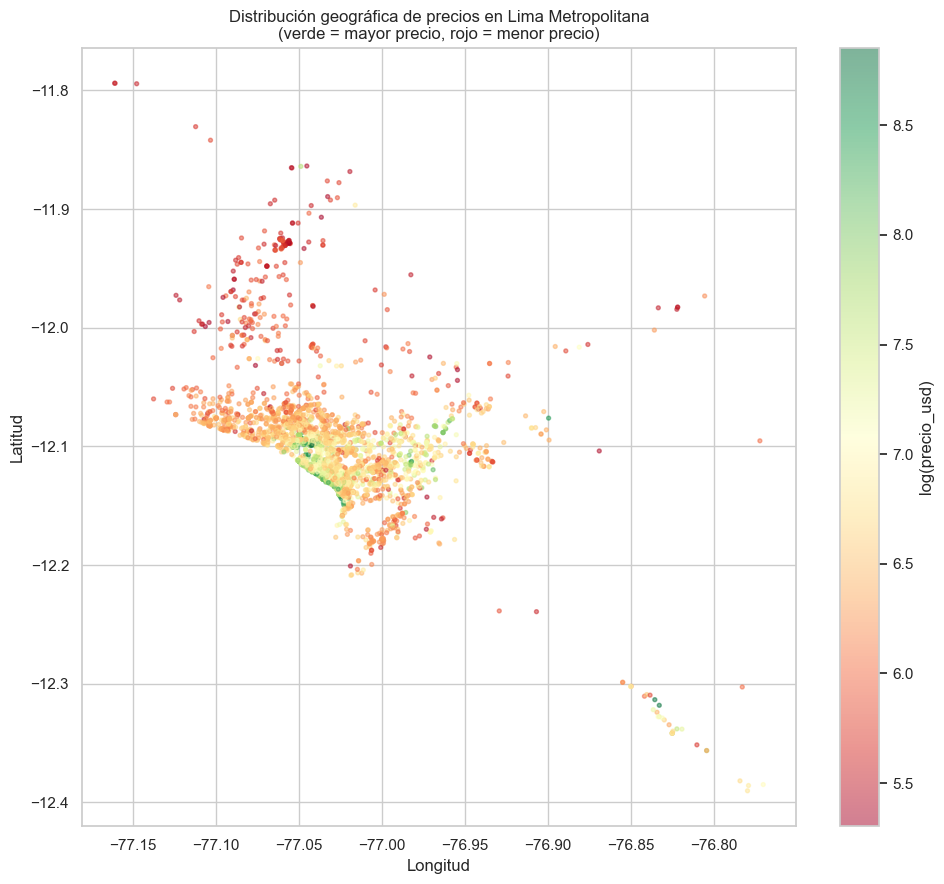

In [9]:
# Scatter geográfico: lat/lon coloreado por precio
fig, ax = plt.subplots(figsize=(10, 9))
sc = ax.scatter(df['longitud'], df['latitud'],
                c=np.log1p(df['precio_usd']),
                cmap='RdYlGn', alpha=0.5, s=8)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('log(precio_usd)')
ax.set_title('Distribución geográfica de precios en Lima Metropolitana\n(verde = mayor precio, rojo = menor precio)')
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
plt.tight_layout()
plt.savefig(f'{FIGURES}02_mapa_precios.png', dpi=150)
plt.show()

---
## 6. Amenities: impacto en el precio

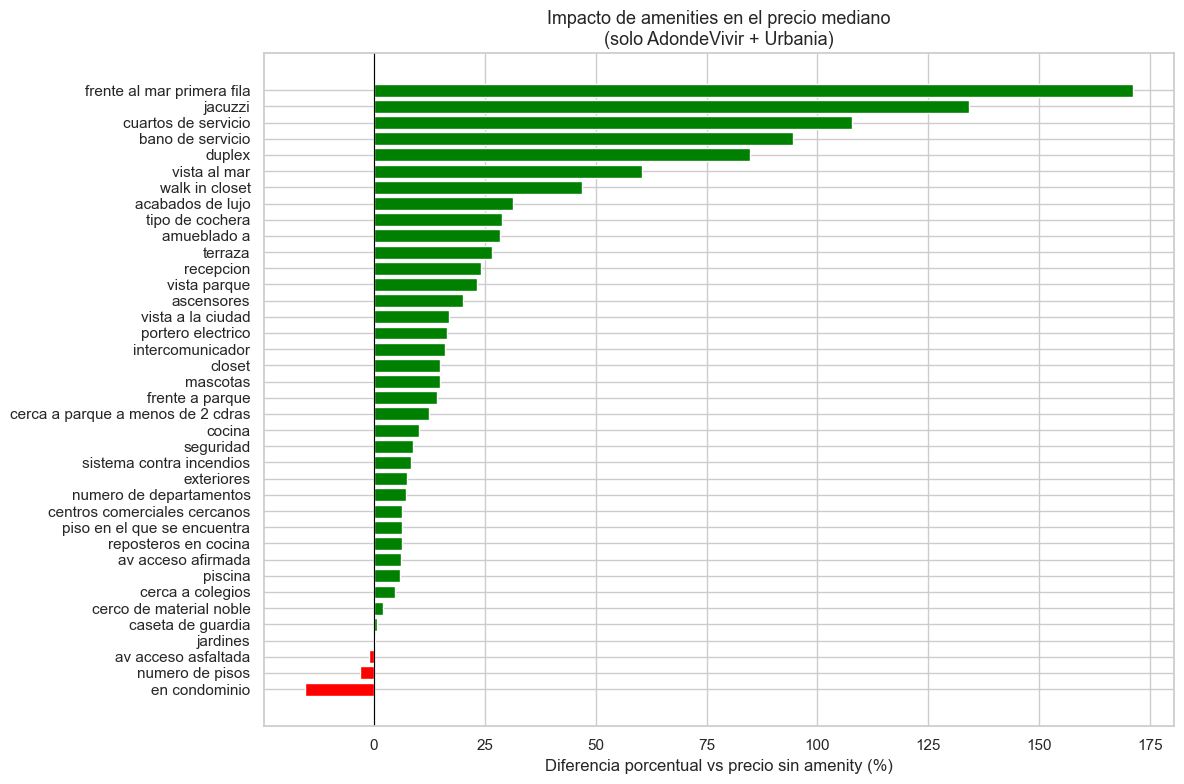

                          amenity  precio_con  precio_sin  diferencia_pct  n_con
       frente al mar primera fila    2200.000     811.590      171.072832     68
                          jacuzzi    1900.000     811.590      134.108355     59
              cuartos de servicio    1600.000     770.360      107.695104    364
                 bano de servicio    1500.000     770.860       94.587863    378
                           duplex    1500.000     811.445       84.855412     86
                     vista al mar    1302.000     811.590       60.425831    146
                   walk in closet    1150.000     782.610       46.944200    399
                 acabados de lujo    1050.000     800.000       31.250000    276
                  tipo de cochera    1000.000     776.000       28.865979    561
                      amueblado a    1000.000     778.855       28.393603    660
                          terraza    1000.000     790.000       26.582278    515
                        rece

In [10]:
amenity_cols = [c for c in df.columns if c.startswith('tiene_')]

# Para listings de AdondeVivir/Urbania (amenities confiables)
df_av = df[df['fuente'] != 'properati'].copy()

# Precio mediano con vs sin cada amenity
impacto = []
for col in amenity_cols:
    con = df_av[df_av[col] == 1]['precio_usd'].median()
    sin = df_av[df_av[col] == 0]['precio_usd'].median()
    n_con = (df_av[col] == 1).sum()
    if n_con >= 30:  # Filtrar amenities con poca representación
        impacto.append({
            'amenity': col.replace('tiene_', '').replace('_', ' '),
            'precio_con': con,
            'precio_sin': sin,
            'diferencia_pct': ((con - sin) / sin * 100) if sin > 0 else 0,
            'n_con': n_con
        })

impacto_df = pd.DataFrame(impacto).sort_values('diferencia_pct', ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
colors = ['green' if x > 0 else 'red' for x in impacto_df['diferencia_pct']]
ax.barh(impacto_df['amenity'][::-1], impacto_df['diferencia_pct'][::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Impacto de amenities en el precio mediano\n(solo AdondeVivir + Urbania)', fontsize=13)
ax.set_xlabel('Diferencia porcentual vs precio sin amenity (%)')
plt.tight_layout()
plt.savefig(f'{FIGURES}02_impacto_amenities.png', dpi=150)
plt.show()

print(impacto_df[['amenity','precio_con','precio_sin','diferencia_pct','n_con']].to_string(index=False))

---
## 7. Mapa de correlaciones

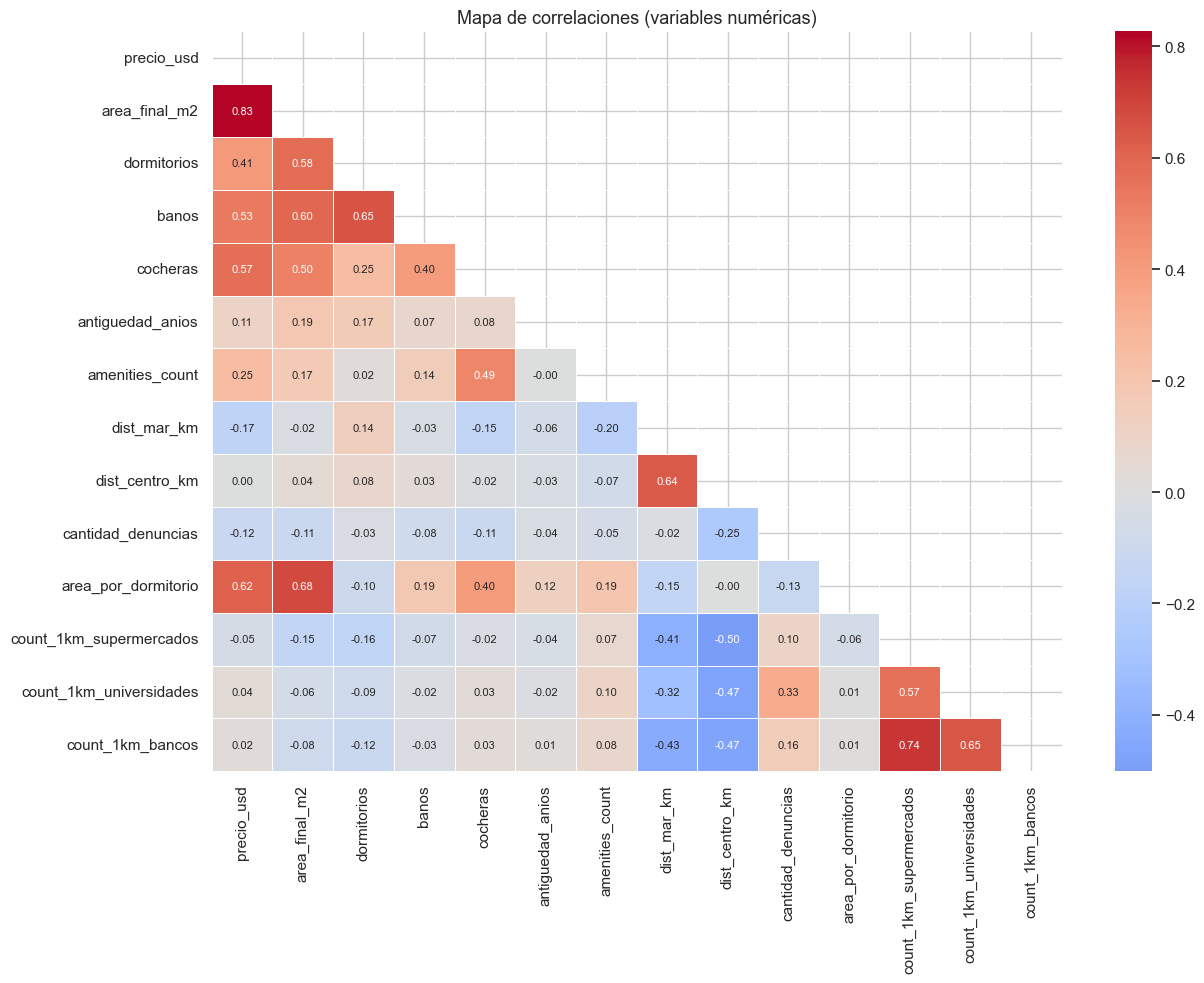


Correlación con precio_usd (ordenado):
area_final_m2              0.827
area_por_dormitorio        0.617
cocheras                   0.569
banos                      0.533
dormitorios                0.410
amenities_count            0.253
antiguedad_anios           0.109
count_1km_universidades    0.037
count_1km_bancos           0.022
dist_centro_km             0.000
count_1km_supermercados   -0.049
cantidad_denuncias        -0.118
dist_mar_km               -0.174
Name: precio_usd, dtype: float64


In [11]:
features_corr = ['precio_usd', 'area_final_m2', 'dormitorios', 'banos', 'cocheras',
                 'antiguedad_anios', 'amenities_count', 'dist_mar_km', 'dist_centro_km',
                 'cantidad_denuncias', 'area_por_dormitorio',
                 'count_1km_supermercados', 'count_1km_universidades', 'count_1km_bancos']

corr_matrix = df[features_corr].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Mapa de correlaciones (variables numéricas)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIGURES}02_correlaciones.png', dpi=150)
plt.show()

# Top correlaciones con el target
print('\nCorrelación con precio_usd (ordenado):')
print(corr_matrix['precio_usd'].drop('precio_usd').sort_values(ascending=False).round(3))

---
## 8. Análisis del mismatch_type

El diccionario indica que `mismatch_type = fraude` significa que el portal declaró un distrito distinto al real para hacer marketing. Exploramos si estos listings tienen precios diferentes.

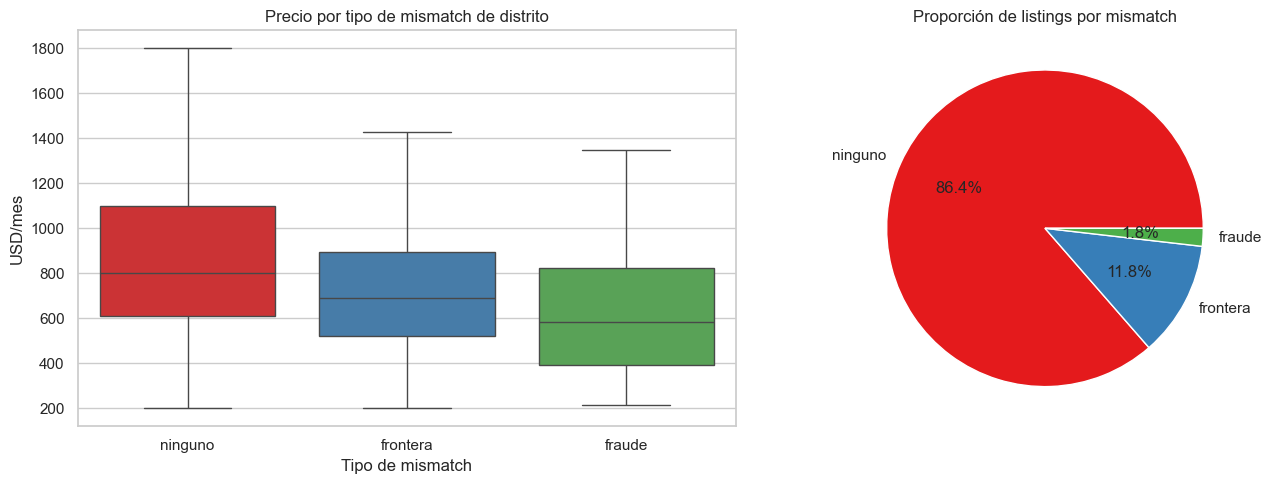

               median    mean  count
mismatch_type                       
fraude          584.0   710.0     61
frontera        690.0   813.0    394
ninguno         800.0  1012.0   2893


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order_mm = df.groupby('mismatch_type')['precio_usd'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='mismatch_type', y='precio_usd', order=order_mm,
            palette='Set1', ax=axes[0], showfliers=False)
axes[0].set_title('Precio por tipo de mismatch de distrito')
axes[0].set_xlabel('Tipo de mismatch')
axes[0].set_ylabel('USD/mes')

conteo_mm = df['mismatch_type'].value_counts()
axes[1].pie(conteo_mm.values, labels=conteo_mm.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set1', len(conteo_mm)))
axes[1].set_title('Proporción de listings por mismatch')

plt.tight_layout()
plt.savefig(f'{FIGURES}02_mismatch.png', dpi=150)
plt.show()

print(df.groupby('mismatch_type')['precio_usd'].agg(['median','mean','count']).round(0))

---
## 9. Conclusiones del EDA

### Hallazgos principales

**Target (`precio_usd`):**
- Distribución con fuerte sesgo positivo → se usará `log1p(precio_usd)` como target en el modelado.
- Rango amplio: desde ~$200 hasta más de $10,000/mes.

**Variables más correlacionadas con el precio:**
- `area_final_m2` es el predictor más fuerte (r ≈ 0.6+).
- `banos` y `dormitorios` tienen correlación positiva esperada.
- `dist_mar_km` tiene correlación negativa: más cerca = más caro.
- `cantidad_denuncias` tiene correlación negativa: más crimen = más barato.

**Geografía:**
- Los distritos más caros son San Isidro, Miraflores y San Borja (zona 'Lima Top').
- Hay una segmentación geográfica muy clara → `distrito_oficial` será una feature muy relevante.

**Amenities:**
- `vista_al_mar`, `acabados_de_lujo` y `jacuzzi` tienen el mayor premium en precio.
- La diferencia con/sin amenity puede superar el 50% en algunos casos.

**Decisiones para el modelado:**
1. Usar `log1p(precio_usd)` como target → revertir con `expm1()` al evaluar.
2. `distrito_oficial` requiere encoding especial (alta cardinalidad: ~49 valores).
3. Las features geoespaciales (`dist_mar_km`, `dist_centro_km`, `latitud`, `longitud`) aportan información complementaria.
4. `amenities_count` es más robusto que las binarias individuales ante el problema de Properati.